# Étape 2 : Préparation et Fusion des Données - PySpark

## Objectif
Créer un dataset unique contenant les données vélo + météo (température + pluie) prêt pour le Machine Learning **en utilisant PySpark**.

## Plan
1. Charger les 3 datasets
2. Nettoyer les formats (virgules → points, dates → timestamp)
3. Agréger les données météo par heure
4. Fusionner les datasets avec LEFT JOIN
5. Remplir les valeurs manquantes (pluie = 0 si absent)
6. Sauvegarder le dataset final

---

## 2.1 Initialisation Spark et Import

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, sum as spark_sum, mean, min as spark_min, max as spark_max,
    to_timestamp, date_format, hour, dayofweek, month,
    regexp_replace, when, lit, floor,
    window
)
from pyspark.sql.types import FloatType, DoubleType, TimestampType
import matplotlib.pyplot as plt
import seaborn as sns

# Créer Spark Session
spark = SparkSession.builder \
    .appName("MeteoVelo - Fusion") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark Session créée!")

Spark Session créée!


## 2.2 Chargement des Datasets

In [2]:
# Chargement des 3 datasets
print("Chargement des datasets...\n")

df_velo = spark.read.csv('../CSVs/counting_data_april_2022.csv', header=True, inferSchema=True, sep=';')
print(f"Vélo : {df_velo.count():,} lignes x {len(df_velo.columns)} colonnes")

df_temp = spark.read.csv('../CSVs/temperature_converted.csv', header=True, inferSchema=True, sep=';')
print(f"Température : {df_temp.count():,} lignes x {len(df_temp.columns)} colonnes")

df_pluie = spark.read.csv('../CSVs/eau_converted.csv', header=True, inferSchema=True, sep=';')
print(f"Pluie : {df_pluie.count():,} lignes x {len(df_pluie.columns)} colonnes")

Chargement des datasets...

Vélo : 262,872 lignes x 5 colonnes
Température : 26,618 lignes x 3 colonnes
Pluie : 5,866 lignes x 3 colonnes


---
## 2.3 Nettoyage des Formats

### Problèmes identifiés :
1. **Température et Pluie** : Format texte avec virgule ("14,75" au lieu de 14.75)
2. **Dates** : Format string au lieu de timestamp

### Solution PySpark :
```python
# Remplacer virgule par point
df = df.withColumn('new_col', regexp_replace(col('old_col'), ',', '.'))

# Convertir en float
df = df.withColumn('new_col', col('new_col').cast(FloatType()))

# Convertir en timestamp
df = df.withColumn('timestamp', to_timestamp(col('date_col')))
```

### 2.3.1 Nettoyage Température

In [3]:
print("Nettoyage des données température...\n")

# AVANT
print("AVANT :")
df_temp.select('degre_celsius').show(5, truncate=False)
df_temp.printSchema()

# 1. Remplacer virgule par point et convertir en float
df_temp = df_temp.withColumn(
    'temperature',
    regexp_replace(col('degre_celsius'), ',', '.').cast(FloatType())
)

# 2. Convertir horodate en timestamp
df_temp = df_temp.withColumn(
    'timestamp',
    to_timestamp(col('horodate'))
)

# APRÈS
print("\nAPRÈS :")
df_temp.select('horodate', 'timestamp', 'degre_celsius', 'temperature', 'deveui').show(5, truncate=False)
df_temp.printSchema()

print("\nTempérature nettoyée!")

Nettoyage des données température...

AVANT :
+-------------+
|degre_celsius|
+-------------+
|14,75        |
|14           |
|13,625       |
|13,5625      |
|15,25        |
+-------------+
only showing top 5 rows

root
 |-- deveui: string (nullable = true)
 |-- horodate: timestamp (nullable = true)
 |-- degre_celsius: string (nullable = true)


APRÈS :
+-------------------+-------------------+-------------+-----------+----------------+
|horodate           |timestamp          |degre_celsius|temperature|deveui          |
+-------------------+-------------------+-------------+-----------+----------------+
|2022-04-29 23:59:00|2022-04-29 23:59:00|14,75        |14.75      |70b3d580a0100605|
|2022-04-29 23:58:00|2022-04-29 23:58:00|14           |14.0       |70b3d580a0100647|
|2022-04-29 23:56:00|2022-04-29 23:56:00|13,625       |13.625     |70b3d580a0100648|
|2022-04-29 23:52:00|2022-04-29 23:52:00|13,5625      |13.5625    |70b3d580a0100623|
|2022-04-29 23:51:00|2022-04-29 23:51:00|15,25   

### 2.3.2 Nettoyage Pluie

In [4]:
print("Nettoyage des données pluviométrie...\n")

# AVANT
print("AVANT :")
df_pluie.select('pluie_mm').show(5, truncate=False)

# 1. Remplacer virgule par point et convertir en float
df_pluie = df_pluie.withColumn(
    'precipitation',
    regexp_replace(col('pluie_mm'), ',', '.').cast(FloatType())
)

# 2. Convertir horodate en timestamp
df_pluie = df_pluie.withColumn(
    'timestamp',
    to_timestamp(col('horodate'))
)

# APRÈS
print("\nAPRÈS :")
df_pluie.select('horodate', 'timestamp', 'pluie_mm', 'precipitation').show(5, truncate=False)
df_pluie.printSchema()

print("\nPluviométrie nettoyée!")

Nettoyage des données pluviométrie...

AVANT :
+--------+
|pluie_mm|
+--------+
|0,1     |
|0,1     |
|0,1     |
|0,1     |
|0,1     |
+--------+
only showing top 5 rows


APRÈS :
+-------------------+-------------------+--------+-------------+
|horodate           |timestamp          |pluie_mm|precipitation|
+-------------------+-------------------+--------+-------------+
|2022-04-29 19:42:00|2022-04-29 19:42:00|0,1     |0.1          |
|2022-04-29 19:36:00|2022-04-29 19:36:00|0,1     |0.1          |
|2022-04-26 00:24:00|2022-04-26 00:24:00|0,1     |0.1          |
|2022-04-26 00:12:00|2022-04-26 00:12:00|0,1     |0.1          |
|2022-04-26 00:06:00|2022-04-26 00:06:00|0,1     |0.1          |
+-------------------+-------------------+--------+-------------+
only showing top 5 rows

root
 |-- identifiant: integer (nullable = true)
 |-- horodate: timestamp (nullable = true)
 |-- pluie_mm: string (nullable = true)
 |-- precipitation: float (nullable = true)
 |-- timestamp: timestamp (nullabl

### 2.3.3 Nettoyage Vélo

In [5]:
print("Nettoyage des données vélo...\n")

# Convertir les dates en timestamp
df_velo = df_velo.withColumn('timestamp', to_timestamp(col('start_datetime')))

print("Dates vélo converties!")
df_velo.select('start_datetime', 'timestamp', 'channel_id', 'count').show(5, truncate=False)

Nettoyage des données vélo...

Dates vélo converties!
+-------------------+-------------------+----------+-----+
|start_datetime     |timestamp          |channel_id|count|
+-------------------+-------------------+----------+-----+
|2022-04-07 01:00:00|2022-04-07 01:00:00|102017788 |0    |
|2022-04-07 00:00:00|2022-04-07 00:00:00|102017788 |0    |
|2022-04-06 23:00:00|2022-04-06 23:00:00|102017788 |0    |
|2022-04-06 22:00:00|2022-04-06 22:00:00|102017788 |0    |
|2022-04-06 21:00:00|2022-04-06 21:00:00|102017788 |0    |
+-------------------+-------------------+----------+-----+
only showing top 5 rows



---
## 2.4 Agrégation des Données par Heure

### Stratégie :
- **Température** : Moyenne des 17 capteurs par heure
- **Pluie** : Moyenne des 31 capteurs par heure
- **Vélo** : Somme de tous les sites par heure

### Étapes PySpark :
1. Arrondir le timestamp à l'heure (enlever minutes/secondes)
2. Grouper par heure avec `.groupBy()`
3. Agréger avec `.agg()` (mean, sum, etc.)

### 2.4.1 Agrégation Température

In [6]:
print("Agrégation température par heure...\n")

# AVANT
print(f"AVANT agrégation : {df_temp.count():,} lignes (multiples capteurs)")
print(f"Nombre de capteurs : {df_temp.select('deveui').distinct().count()}")

# Arrondir le timestamp à l'heure (enlever les minutes)
# date_trunc('hour', timestamp) fait la même chose
df_temp = df_temp.withColumn(
    'timestamp_hour',
    date_format(col('timestamp'), 'yyyy-MM-dd HH:00:00').cast(TimestampType())
)

# Agréger : moyenne des températures par heure
df_temp_agg = df_temp.groupBy('timestamp_hour') \
    .agg(mean('temperature').alias('temperature')) \
    .withColumnRenamed('timestamp_hour', 'timestamp') \
    .orderBy('timestamp')

# APRÈS
print(f"\nAPRÈS agrégation : {df_temp_agg.count():,} lignes (1 valeur par heure)")
print(f"Plage de dates : {df_temp_agg.agg(spark_min('timestamp')).collect()[0][0]} → {df_temp_agg.agg(spark_max('timestamp')).collect()[0][0]}")

print("\nTempérature agrégée par heure!")
df_temp_agg.show(10, truncate=False)

Agrégation température par heure...

AVANT agrégation : 26,618 lignes (multiples capteurs)
Nombre de capteurs : 17

APRÈS agrégation : 696 lignes (1 valeur par heure)
Plage de dates : 2022-04-01 00:00:00 → 2022-04-29 23:00:00

Température agrégée par heure!
+-------------------+------------------+
|timestamp          |temperature       |
+-------------------+------------------+
|2022-04-01 00:00:00|7.3980263157894735|
|2022-04-01 01:00:00|6.958333333333333 |
|2022-04-01 02:00:00|6.493589743589744 |
|2022-04-01 03:00:00|4.5082236842105265|
|2022-04-01 04:00:00|2.695723684210526 |
|2022-04-01 05:00:00|2.10625           |
|2022-04-01 06:00:00|1.5480769230769231|
|2022-04-01 07:00:00|1.3658088235294117|
|2022-04-01 08:00:00|1.5135135135135136|
|2022-04-01 09:00:00|1.8597972972972974|
+-------------------+------------------+
only showing top 10 rows



### 2.4.2 Agrégation Pluie

In [7]:
print("Agrégation pluviométrie par heure...\n")

# AVANT
print(f"AVANT agrégation : {df_pluie.count():,} lignes (multiples capteurs)")
print(f"Nombre de capteurs : {df_pluie.select('identifiant').distinct().count()}")

# Arrondir à l'heure
df_pluie = df_pluie.withColumn(
    'timestamp_hour',
    date_format(col('timestamp'), 'yyyy-MM-dd HH:00:00').cast(TimestampType())
)

# Agréger : moyenne des précipitations par heure
df_pluie_agg = df_pluie.groupBy('timestamp_hour') \
    .agg(mean('precipitation').alias('precipitation')) \
    .withColumnRenamed('timestamp_hour', 'timestamp') \
    .orderBy('timestamp')

# APRÈS
print(f"\nAPRÈS agrégation : {df_pluie_agg.count():,} lignes (1 valeur par heure de pluie)")
print(f"Plage de dates : {df_pluie_agg.agg(spark_min('timestamp')).collect()[0][0]} → {df_pluie_agg.agg(spark_max('timestamp')).collect()[0][0]}")

print("\n⚠RAPPEL : Ce dataset ne contient QUE les heures où il a plu!")
print("→ Les heures sans pluie seront ajoutées à 0mm lors de la fusion.")

print("\nPluviométrie agrégée par heure!")
df_pluie_agg.show(10, truncate=False)

Agrégation pluviométrie par heure...

AVANT agrégation : 5,866 lignes (multiples capteurs)
Nombre de capteurs : 31

APRÈS agrégation : 116 lignes (1 valeur par heure de pluie)
Plage de dates : 2022-04-01 00:00:00 → 2022-04-29 20:00:00

⚠RAPPEL : Ce dataset ne contient QUE les heures où il a plu!
→ Les heures sans pluie seront ajoutées à 0mm lors de la fusion.

Pluviométrie agrégée par heure!
+-------------------+-------------------+
|timestamp          |precipitation      |
+-------------------+-------------------+
|2022-04-01 00:00:00|0.10000000149011612|
|2022-04-01 02:00:00|0.10000000149011612|
|2022-04-01 03:00:00|0.18252427572185553|
|2022-04-01 04:00:00|0.1714953304938624 |
|2022-04-01 05:00:00|0.15500000279683332|
|2022-04-01 06:00:00|0.16033898617251444|
|2022-04-01 07:00:00|0.14008439052457045|
|2022-04-01 08:00:00|0.12518518716096877|
|2022-04-01 09:00:00|0.10000000149011612|
|2022-04-01 10:00:00|0.1793103482702683 |
+-------------------+-------------------+
only showing top 

### 2.4.3 Agrégation Vélo

In [8]:
print("Agrégation vélo par heure (somme de tous les sites)...\n")

# AVANT
print(f"AVANT agrégation : {df_velo.count():,} lignes (multiples sites)")
print(f"Nombre de sites différents : {df_velo.select('channel_id').distinct().count()}")

# Arrondir à l'heure
df_velo = df_velo.withColumn(
    'timestamp_hour',
    date_format(col('timestamp'), 'yyyy-MM-dd HH:00:00').cast(TimestampType())
)

# Agréger : SOMME des vélos de TOUS les sites par heure
df_velo_agg = df_velo.groupBy('timestamp_hour') \
    .agg(spark_sum('count').alias('nb_velos')) \
    .withColumnRenamed('timestamp_hour', 'timestamp') \
    .orderBy('timestamp')

# APRÈS
print(f"\nAPRÈS agrégation : {df_velo_agg.count():,} lignes (1 total par heure)")
print(f"Plage de dates : {df_velo_agg.agg(spark_min('timestamp')).collect()[0][0]} → {df_velo_agg.agg(spark_max('timestamp')).collect()[0][0]}")

print("\nVélos agrégés par heure!")
df_velo_agg.show(10, truncate=False)

Agrégation vélo par heure (somme de tous les sites)...

AVANT agrégation : 262,872 lignes (multiples sites)
Nombre de sites différents : 376

APRÈS agrégation : 696 lignes (1 total par heure)
Plage de dates : 2022-04-01 00:00:00 → 2022-04-29 23:00:00

Vélos agrégés par heure!
+-------------------+--------+
|timestamp          |nb_velos|
+-------------------+--------+
|2022-04-01 00:00:00|3607    |
|2022-04-01 01:00:00|1762    |
|2022-04-01 02:00:00|1207    |
|2022-04-01 03:00:00|878     |
|2022-04-01 04:00:00|652     |
|2022-04-01 05:00:00|885     |
|2022-04-01 06:00:00|2315    |
|2022-04-01 07:00:00|9696    |
|2022-04-01 08:00:00|21176   |
|2022-04-01 09:00:00|11340   |
+-------------------+--------+
only showing top 10 rows



In [9]:
# Statistiques sur les vélos agrégés
print("Statistiques du trafic vélo total Lyon par heure :")
print("="*80)
df_velo_agg.describe('nb_velos').show()

stats = df_velo_agg.agg(
    spark_max('nb_velos').alias('max'),
    spark_min('nb_velos').alias('min'),
    mean('nb_velos').alias('mean')
).collect()[0]

print(f"\nHeure la plus chargée : {stats['max']:,} vélos")
print(f"Heure la moins chargée : {stats['min']:,} vélos")
print(f"Moyenne : {stats['mean']:.0f} vélos/heure")

Statistiques du trafic vélo total Lyon par heure :
+-------+-----------------+
|summary|         nb_velos|
+-------+-----------------+
|  count|              696|
|   mean|10072.78591954023|
| stddev|9024.364654341893|
|    min|              225|
|    max|            44073|
+-------+-----------------+


Heure la plus chargée : 44,073 vélos
Heure la moins chargée : 225 vélos
Moyenne : 10073 vélos/heure


---
## 2.5 Fusion des Datasets

### Stratégie de Fusion (LEFT JOIN) :
```
1. df_velo (base) LEFT JOIN df_temp (température)
2. Résultat        LEFT JOIN df_pluie (pluie)
```

**Pourquoi LEFT JOIN ?**
- On garde TOUTES les heures du dataset vélo (notre cible)
- Si une heure n'a pas de température → NULL
- Si une heure n'a pas de pluie → NULL → on remplacera par 0mm

In [10]:
print("Fusion des datasets...\n")

# Étape 1 : Merger Vélo + Température
print("Étape 1/2 : Fusion Vélo + Température")
df_merged = df_velo_agg.join(df_temp_agg, on='timestamp', how='left')
print(f"Résultat : {df_merged.count():,} lignes")

# Étape 2 : Merger avec Pluie
print("\nÉtape 2/2 : Fusion + Pluie")
df_merged = df_merged.join(df_pluie_agg, on='timestamp', how='left')
print(f"Résultat : {df_merged.count():,} lignes")

print("\n" + "="*80)
print("Dataset fusionné :")
print("="*80)
df_merged.show(10, truncate=False)

Fusion des datasets...

Étape 1/2 : Fusion Vélo + Température
Résultat : 696 lignes

Étape 2/2 : Fusion + Pluie
Résultat : 696 lignes

Dataset fusionné :
+-------------------+--------+------------------+-------------------+
|timestamp          |nb_velos|temperature       |precipitation      |
+-------------------+--------+------------------+-------------------+
|2022-04-05 14:00:00|11210   |13.191761363636363|NULL               |
|2022-04-07 02:00:00|803     |10.81859756097561 |NULL               |
|2022-04-17 18:00:00|13995   |18.738970588235293|NULL               |
|2022-04-26 14:00:00|10540   |17.0859375        |NULL               |
|2022-04-24 21:00:00|2863    |13.11111111111111 |0.2724696412260233 |
|2022-04-21 05:00:00|1153    |12.90548780487805 |0.10000000149011612|
|2022-04-15 14:00:00|14809   |21.92361111111111 |NULL               |
|2022-04-26 04:00:00|579     |11.27027027027027 |NULL               |
|2022-04-24 09:00:00|5588    |10.123214285714285|NULL               |
|2022-

In [11]:
# Vérifier les valeurs manquantes après fusion
print("Vérification des valeurs manquantes après fusion :")
print("="*80)

total_rows = df_merged.count()
for col_name in df_merged.columns:
    null_count = df_merged.filter(col(col_name).isNull()).count()
    null_pct = (null_count / total_rows) * 100
    print(f"{col_name:<20} {null_count:>6} ({null_pct:>6.2f}%)")

Vérification des valeurs manquantes après fusion :
timestamp                 0 (  0.00%)
nb_velos                  0 (  0.00%)
temperature               0 (  0.00%)
precipitation           580 ( 83.33%)


---
## 2.6 Gestion des Valeurs Manquantes

### Stratégie :
1. **Pluie (precipitation)** → Remplacer NULL par **0** (pas de pluie)
2. **Température** → Si NULL, interpolation ou suppression des lignes

In [12]:
print("Gestion des valeurs manquantes...\n")

# 1. Remplir les NULL de pluie par 0
print("Pluie : NULL → 0mm (pas de pluie)")
nb_null_pluie_avant = df_merged.filter(col('precipitation').isNull()).count()
df_merged = df_merged.fillna({'precipitation': 0.0})
print(f" {nb_null_pluie_avant:,} valeurs remplacées par 0\n")

# 2. Gérer les NULL de température
nb_null_temp = df_merged.filter(col('temperature').isNull()).count()
print(f"Température : {nb_null_temp:,} valeurs manquantes")

if nb_null_temp > 0:
    print("→ Stratégie : Supprimer les lignes avec température NULL")
    df_merged = df_merged.filter(col('temperature').isNotNull())
    print(f"{nb_null_temp:,} lignes supprimées")
else:
    print("Aucune valeur manquante!")

print("\n" + "="*80)
print("Vérification finale :")
print("="*80)

total_rows = df_merged.count()
for col_name in df_merged.columns:
    null_count = df_merged.filter(col(col_name).isNull()).count()
    print(f"{col_name:<20} {null_count:>6} NULL")

Gestion des valeurs manquantes...

Pluie : NULL → 0mm (pas de pluie)
 580 valeurs remplacées par 0

Température : 0 valeurs manquantes
Aucune valeur manquante!

Vérification finale :
timestamp                 0 NULL
nb_velos                  0 NULL
temperature               0 NULL
precipitation             0 NULL


---
## 2.7 Visualisations du Dataset Fusionné

In [13]:
# Aperçu final du dataset
print("Dataset final fusionné :")
print("="*80)
print(f"Dimensions : {df_merged.count():,} lignes x {len(df_merged.columns)} colonnes")

min_max = df_merged.agg(
    spark_min('timestamp').alias('min'),
    spark_max('timestamp').alias('max')
).collect()[0]
print(f"Période : {min_max['min']} → {min_max['max']}")

print("\nColonnes :")
for col_name in df_merged.columns:
    col_type = [f.dataType for f in df_merged.schema.fields if f.name == col_name][0]
    print(f"  - {col_name} ({col_type})")

print("\n" + "="*80)
df_merged.show(10, truncate=False)

Dataset final fusionné :
Dimensions : 696 lignes x 4 colonnes
Période : 2022-04-01 00:00:00 → 2022-04-29 23:00:00

Colonnes :
  - timestamp (TimestampType())
  - nb_velos (LongType())
  - temperature (DoubleType())
  - precipitation (DoubleType())

+-------------------+--------+------------------+-------------------+
|timestamp          |nb_velos|temperature       |precipitation      |
+-------------------+--------+------------------+-------------------+
|2022-04-05 14:00:00|11210   |13.191761363636363|0.0                |
|2022-04-07 02:00:00|803     |10.81859756097561 |0.0                |
|2022-04-17 18:00:00|13995   |18.738970588235293|0.0                |
|2022-04-26 14:00:00|10540   |17.0859375        |0.0                |
|2022-04-24 21:00:00|2863    |13.11111111111111 |0.2724696412260233 |
|2022-04-21 05:00:00|1153    |12.90548780487805 |0.10000000149011612|
|2022-04-15 14:00:00|14809   |21.92361111111111 |0.0                |
|2022-04-26 04:00:00|579     |11.27027027027027 |0.

In [14]:
# Statistiques descriptives
print("Statistiques du dataset fusionné :")
print("="*80)
df_merged.describe().show()

Statistiques du dataset fusionné :
+-------+-----------------+------------------+--------------------+
|summary|         nb_velos|       temperature|       precipitation|
+-------+-----------------+------------------+--------------------+
|  count|              696|               696|                 696|
|   mean|10072.78591954023|12.710508000967215|0.025614590499973507|
| stddev|9024.364654341887| 5.416149960525319| 0.06977961759361191|
|    min|              225|0.2944078947368421|                 0.0|
|    max|            44073| 22.66282894736842|  0.7692307686576476|
+-------+-----------------+------------------+--------------------+



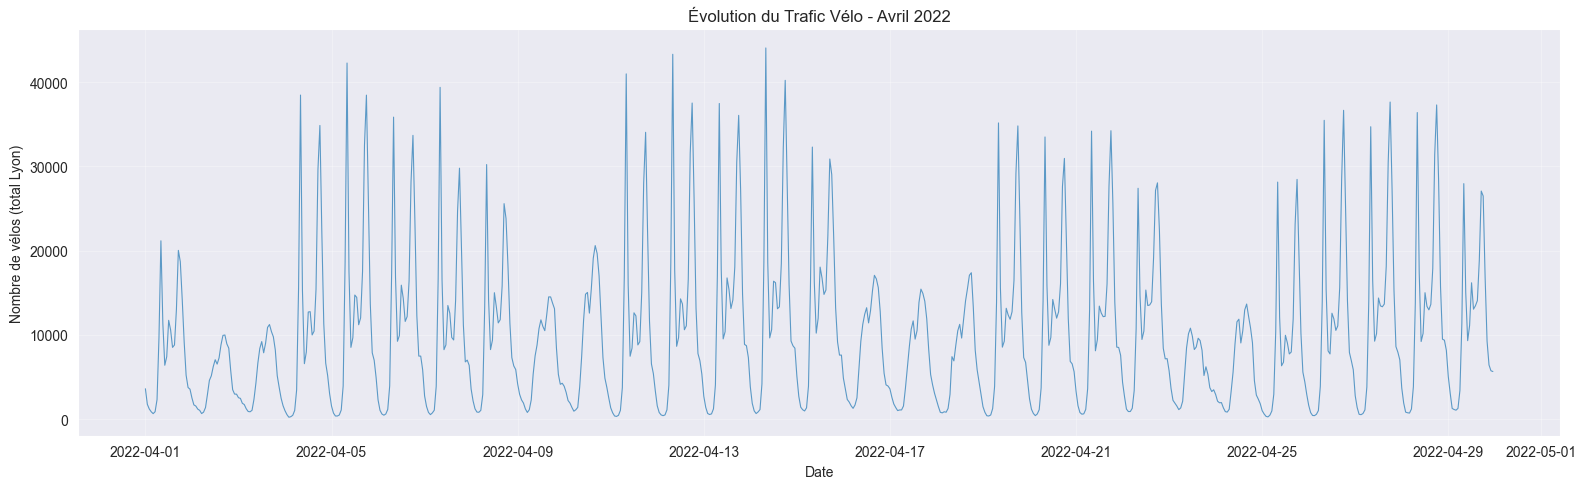

On voit bien les patterns jour/nuit et semaine/weekend


In [15]:
# Visualisation : convertir en Pandas pour matplotlib
df_pandas = df_merged.orderBy('timestamp').toPandas()

# Graphique 1 : Évolution du trafic vélo
plt.figure(figsize=(16, 5))
plt.plot(df_pandas['timestamp'], df_pandas['nb_velos'], linewidth=0.8, alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Nombre de vélos (total Lyon)')
plt.title('Évolution du Trafic Vélo - Avril 2022')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("On voit bien les patterns jour/nuit et semaine/weekend")

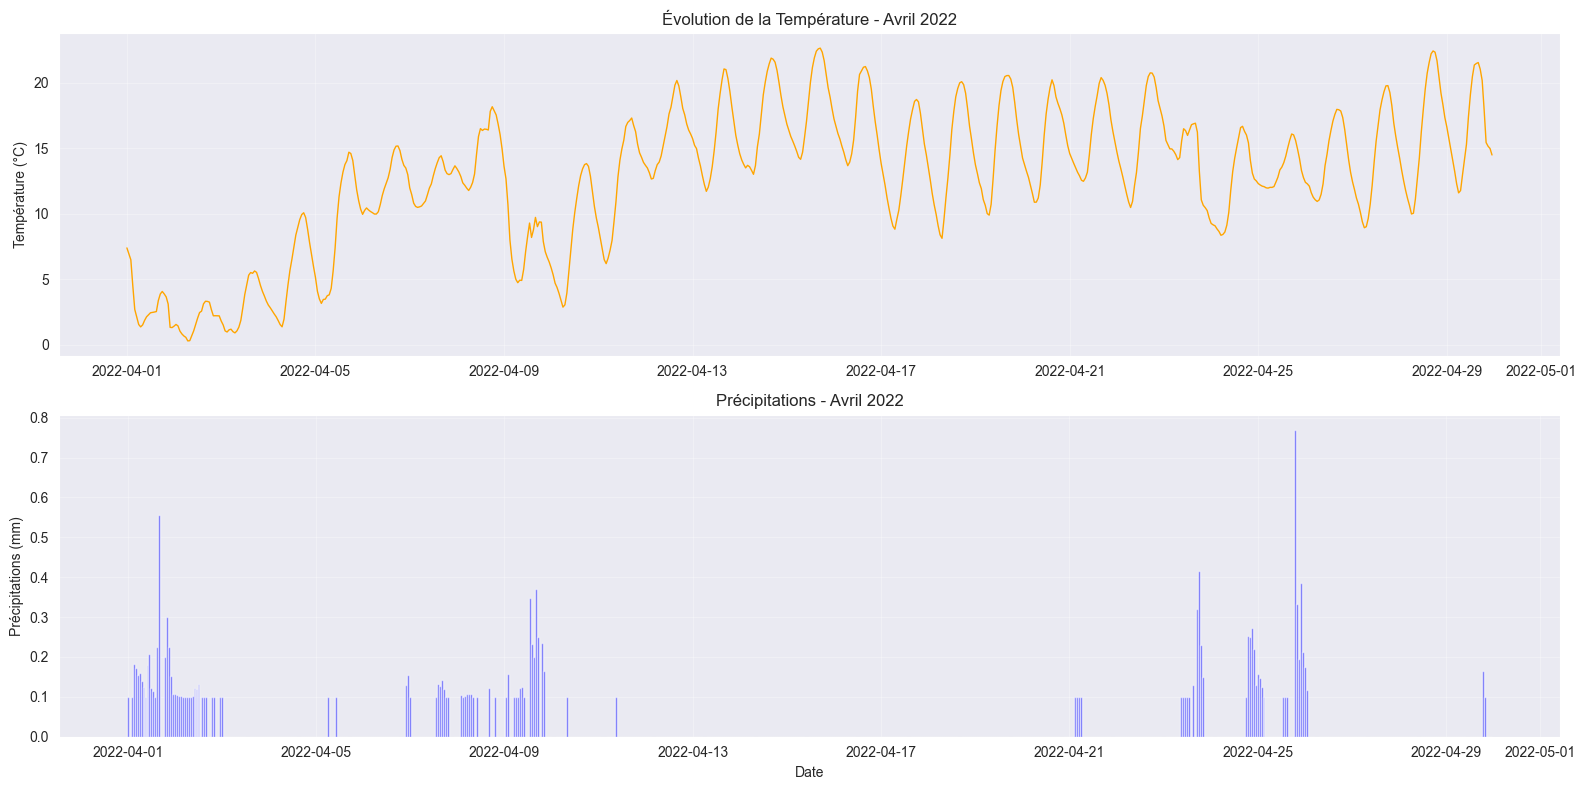

On voit bien les 16 jours de pluie identifiés précédemment


In [16]:
# Graphique 2 : Température et Pluie
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Température
axes[0].plot(df_pandas['timestamp'], df_pandas['temperature'], color='orange', linewidth=1)
axes[0].set_ylabel('Température (°C)')
axes[0].set_title('Évolution de la Température - Avril 2022')
axes[0].grid(True, alpha=0.3)

# Pluie
axes[1].bar(df_pandas['timestamp'], df_pandas['precipitation'], width=0.04, color='blue', alpha=0.6)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Précipitations (mm)')
axes[1].set_title('Précipitations - Avril 2022')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("On voit bien les 16 jours de pluie identifiés précédemment")

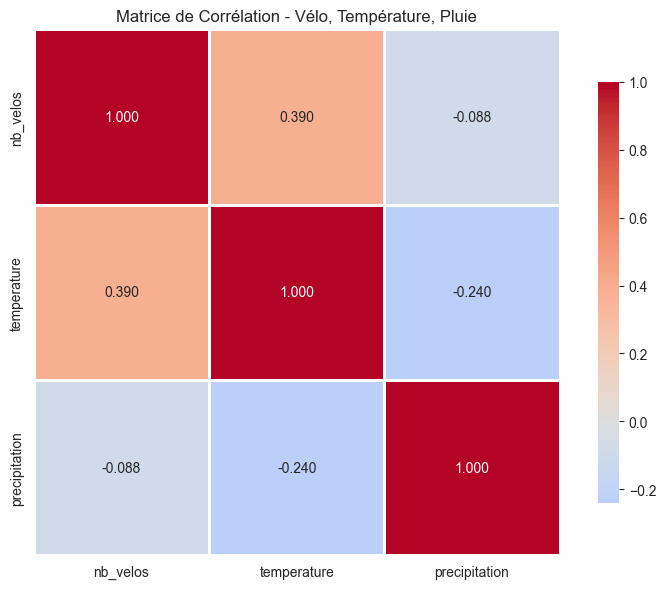


Interprétation :
Corrélation Vélo ↔ Température : 0.390
Corrélation Vélo ↔ Pluie : -0.088


In [17]:
# Graphique 3 : Matrice de corrélation
import numpy as np

plt.figure(figsize=(8, 6))

# Calculer la corrélation
corr_matrix = df_pandas[['nb_velos', 'temperature', 'precipitation']].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation - Vélo, Température, Pluie')
plt.tight_layout()
plt.show()

print("\nInterprétation :")
print(f"Corrélation Vélo ↔ Température : {corr_matrix.loc['nb_velos', 'temperature']:.3f}")
print(f"Corrélation Vélo ↔ Pluie : {corr_matrix.loc['nb_velos', 'precipitation']:.3f}")

---
## 2.8 Sauvegarde du Dataset Final

In [18]:
# Sauvegarder le dataset fusionné
output_path = '../CSVs/data_merged_spark.csv'

# Option 1 : Sauvegarder avec Spark (peut créer plusieurs fichiers)
# df_merged.write.csv(output_path, header=True, mode='overwrite', sep=';')

# Option 2 : Convertir en Pandas et sauvegarder (1 seul fichier)
df_pandas_final = df_merged.orderBy('timestamp').toPandas()
df_pandas_final.to_csv(output_path, index=False, sep=';')

print("Dataset fusionné sauvegardé!")
print("="*80)
print(f"Fichier : {output_path}")
print(f"Dimensions : {df_merged.count():,} lignes x {len(df_merged.columns)} colonnes")
print(f"Période : {min_max['min']} → {min_max['max']}")
print("\nPrêt pour l'étape 3 : Feature Engineering!")

Dataset fusionné sauvegardé!
Fichier : ../CSVs/data_merged_spark.csv
Dimensions : 696 lignes x 4 colonnes
Période : 2022-04-01 00:00:00 → 2022-04-29 23:00:00

Prêt pour l'étape 3 : Feature Engineering!


---
## 2.9 Résumé de l'Étape 2

### Ce qui a été fait :

1. **Nettoyage des formats**
   - Conversion virgule → point : `regexp_replace()`
   - Conversion STRING → FLOAT : `.cast(FloatType())`
   - Conversion STRING → TIMESTAMP : `to_timestamp()`

2. **Agrégation temporelle (heure)**
   - Arrondi à l'heure : `date_format(..., 'yyyy-MM-dd HH:00:00')`
   - Température : Moyenne des 17 capteurs → `.groupBy().agg(mean())`
   - Pluie : Moyenne des 31 capteurs → `.groupBy().agg(mean())`
   - Vélo : Somme de tous les sites → `.groupBy().agg(sum())`

3. **Fusion avec LEFT JOIN**
   - Conservation de toutes les heures du dataset vélo
   - `.join(df, on='timestamp', how='left')`

4. **Gestion des valeurs manquantes**
   - Pluie NULL → 0mm : `.fillna({'precipitation': 0.0})`
   - Température NULL → Lignes supprimées

5. **Visualisations**
   - Conversion Spark → Pandas : `.toPandas()`
   - Graphiques matplotlib/seaborn

### Dataset Final :
- **Colonnes** : `timestamp`, `nb_velos`, `temperature`, `precipitation`
- **Granularité** : Horaire
- **Fichier** : `data_merged_spark.csv`

### Prochaine Étape :
**Étape 3 : Feature Engineering**
- Créer des features temporelles (heure, jour, weekend...)
- Créer des features météo enrichies
- Encoder les variables catégorielles

---
**Étape 2 terminée !**

In [19]:
# Arrêter la Spark Session
spark.stop()
print("Spark Session arrêtée!")

✅ Spark Session arrêtée!
